<a href="https://colab.research.google.com/github/AlvaroAceval16/MachineLearning/blob/main/P5_Maquinas_de_Soporte_SVR_Automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Cargar Datos Y Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
 #Cargar el dataset

from google.colab import drive
drive.mount('/content/drive')
 # https://drive.google.com/file/d/1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf/view?usp=drive_link
file_id = '1qNC76DVrW_w65ny-MxSf7ETqpG3lV9zf'

#URL de descarga directa
url = f'https://drive.google.com/uc?id={file_id}'

#Leer el archivo CSV directamente desde la URL
df = pd.read_csv(url)

# --- Inicia la corrección del error ---
# Identificar columnas que deben ser numéricas y podrían contener '?'
numeric_cols = ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore', 'price']

# Reemplazar '?' con NaN y convertir a numérico
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].replace('?', np.nan)
        df[col] = pd.to_numeric(df[col])

# Imputar valores faltantes con la media
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
# --- Termina la corrección del error ---

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Definir variables predictoras y variable objetivo
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [ ]:
#  3. Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. Escalamiento de variables
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [ ]:
# 5. Entrenar modelo SVR
svr_model = SVR(kernel='rbf', C=100, epsilon=0.2)
# Entrenar el modelo con los datos escalados
svr_model.fit(X_train_scaled, y_train_scaled)

SVR(C=100, epsilon=0.2)

In [ ]:
# 6. Evaluar el modelo
 # Predecir valores con datos de prueba escalados
y_pred_scaled = svr_model.predict(X_test_scaled)
# Desescala las Predicciones: Usamos el mismo objeto StandardScaler
# para escalar y (el precio) para revertir la escala:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
# Calcula las métricas comparando las predicciones desescaladas (y_pred)
# con las etiquetas de prueba originales (y_test):
mse_svr = mean_squared_error(y_test, y_pred)
r2_svr = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse_svr:.2f}")
print(f"Coeficiente de determinación (R²): {r2_svr:.2f}")

Error cuadrático medio (MSE): 13172398.73
Coeficiente de determinación (R²): 0.83


In [ ]:
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse_svr)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 3629.38


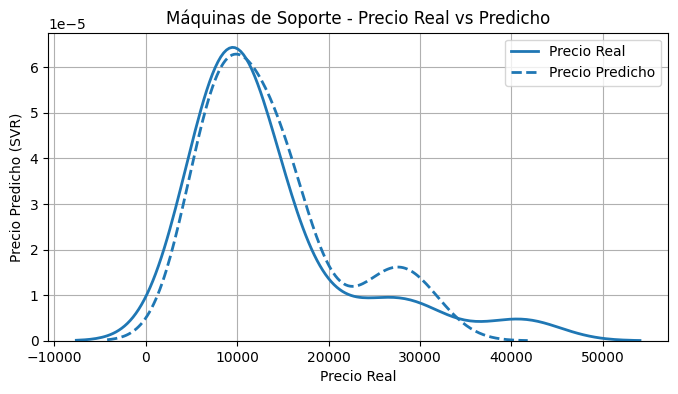

In [ ]:
# 7. Comparar precios reales vs predichos
 #plt.scatter(y_test, y_pred, color='purple')
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (SVR)")
plt.title("Máquinas de Soporte - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

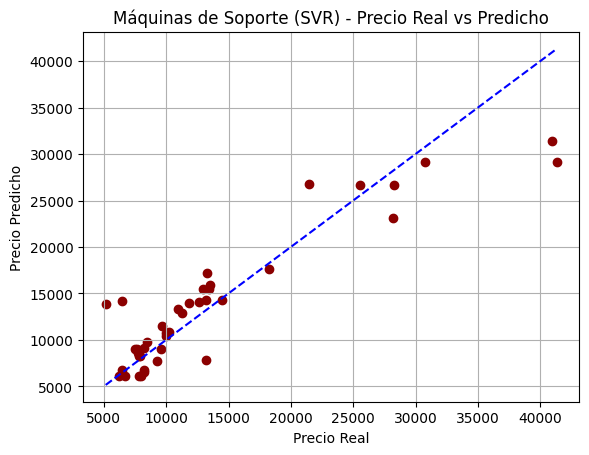

In [ ]:
# Comparar precios con diagrama de dispersión
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Máquinas de Soporte (SVR) - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [ ]:
# Búsqueda de mejores parámetros
from sklearn.model_selection import GridSearchCV
# Parámetros a probar
param_grid = {
'kernel': ['linear', 'rbf', 'poly'],
'C': [0.1, 1, 10, 100],
'epsilon': [0.01, 0.1, 1],
'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}
# Inicialización y ajuste usando datos escalados
grid_search = GridSearchCV( SVR(), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train_scaled) # Entrena con datos escalados
# Mejor modelo
best_svr = grid_search.best_estimator_
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)
# Predecir valores con datos de prueba escalados
y_pred_scaled = best_svr.predict(X_test_scaled) # Se usa X_test_scaled


# B. Desescala las Predicciones
# La predicción (y_pred_scaled) está en la escala de Y (0 a 1).
# Debemos devolverla a la escala de precio original usando scaler_y.
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
# Calcular métricas (comparando predicción desescalada con y_test original)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\n Resultados del mejor modelo:")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del error cuadrático medio (RMSE): {np.sqrt(mse):.2f}")

Fitting 3 folds for each of 180 candidates, totalling 540 fits

 Mejores parámetros encontrados:
{'C': 10, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}

 Resultados del mejor modelo:
Error cuadrático medio (MSE): 12909757.39
Coeficiente de determinación (R²): 0.83
Raíz del error cuadrático medio (RMSE): 3593.02
